In [1]:
import pandas as pd

## **Random Forest Algorithm for Classification Problem**

Below is a Python example using *Random Forest Algorithm* for a classification task on the Iris dataset:

### **Data Preprocessing**

#### **Data Collection & Cleaning**

In [2]:
data = pd.read_csv("../datasets/Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
data = data.drop(columns=["Id"])
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
x_vals = data.iloc[ : , 0:4]
x_vals.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
x_vals.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')

In [11]:
y_vals = data.Species
y_vals.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

#### **Feature Scaling**

- Feature scaling is not required for tree based algorithms such as `Decision tree & Random Forest Algorithms`.

#### **Data Splitting**

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x_vals, y_vals)
len(x_train)

112

In [14]:
len(x_test)

38

### **Model Training**

- **RandomForestClassifier** Class used to *classification problems*

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
model = RandomForestClassifier(n_estimators=5) # n_estimators : number of decision trees in forest.
model.fit(X=x_train, y=y_train)

RandomForestClassifier(n_estimators=5)

- **Prediction**

In [17]:
y_pred = model.predict(x_test)
y_pred[0:5]

array(['Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-setosa'], dtype=object)

In [18]:
y_test[0:5]

83     Iris-versicolor
87     Iris-versicolor
101     Iris-virginica
35         Iris-setosa
47         Iris-setosa
Name: Species, dtype: object

### **Model Evaluation**

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9473684210526315

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  0,  0],
       [ 0, 13,  1],
       [ 0,  1, 10]], dtype=int64)

In [23]:
# Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=x_vals.columns)
print("Feature Importance:")
print(feature_importance.sort_values(ascending=False))

Feature Importance:
PetalWidthCm     0.608394
PetalLengthCm    0.285616
SepalLengthCm    0.085718
SepalWidthCm     0.020273
dtype: float64


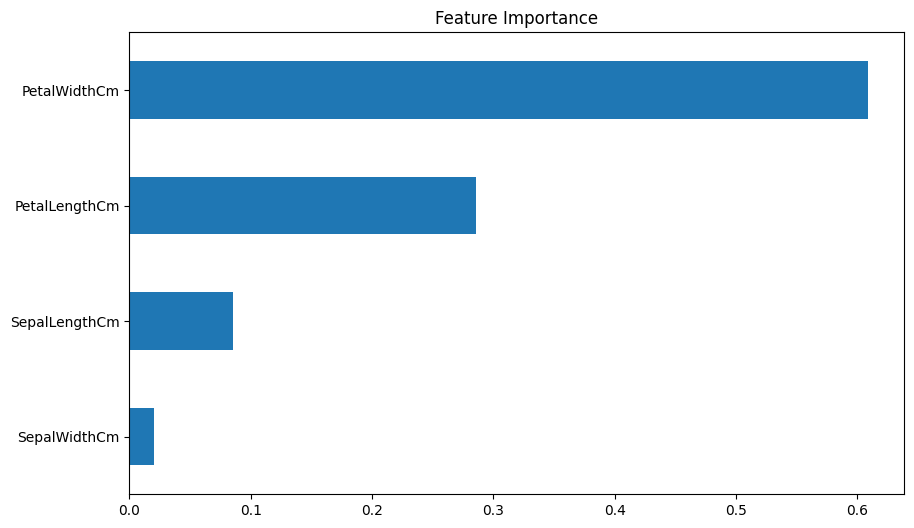

In [24]:
import matplotlib.pyplot as plt

# Visualize Feature Importance
feature_importance.sort_values().plot(kind='barh', title="Feature Importance", figsize=(10, 6))
plt.show()